Anna De Martin, ID: 16198921

**Introduction to Computational Science**

*Assignment 1: SIR model (ODE)*



In [215]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import least_squares
from scipy import fft

**Problem 1: Numerical integration of the SIR model**

Consider the basic model, where we assume fixed population, i.e. $S + I + R = 1$. The spread
of infection goes in one direction from susceptible to infected to recovered. Once an
individual is recovered he or she can no longer become susceptible.

In [216]:
# Implement basic SIR model
def SIR_basic(t, z, beta, gamma):
    S, I, R = z[0], z[1], z[2]
    dSdt = -beta * S * I
    dIdt = beta * S * I - gamma * I
    dRdt = gamma * I
    return [dSdt, dIdt, dRdt]

**1.1** The parameter that determines if the infectious disease will become an epidemic is $R_0 = \beta / \gamma$. If $R_0 > 1$, then the epidemic will spread. 

We compare two different scenarios for two different values of $R_0$. We numerically integrate the above ODEs and provide the phase space diagrams for the (S, I) ax[idx].

In [217]:
# Find numerical solution with solve_ivp
def SIR_basic_solve(y0, beta, gamma, T = 90, steps = 1000):
    t_span = (0.0, T)
    t_eval = np.linspace(0.0, T, steps)
    sol = solve_ivp(
        SIR_basic, t_span, y0, t_eval=t_eval, args=(beta, gamma),
    )
    return sol.t, sol.y[0], sol.y[1], sol.y[2]

In [218]:
# Set initial values for susceptible (S), infected (I), and recovered (R) populations
i0 = 0.01
s0 = 1.0 - i0
r0 = 0.0
assert i0 + s0 + r0 == 1

y0 = [s0, i0, r0]

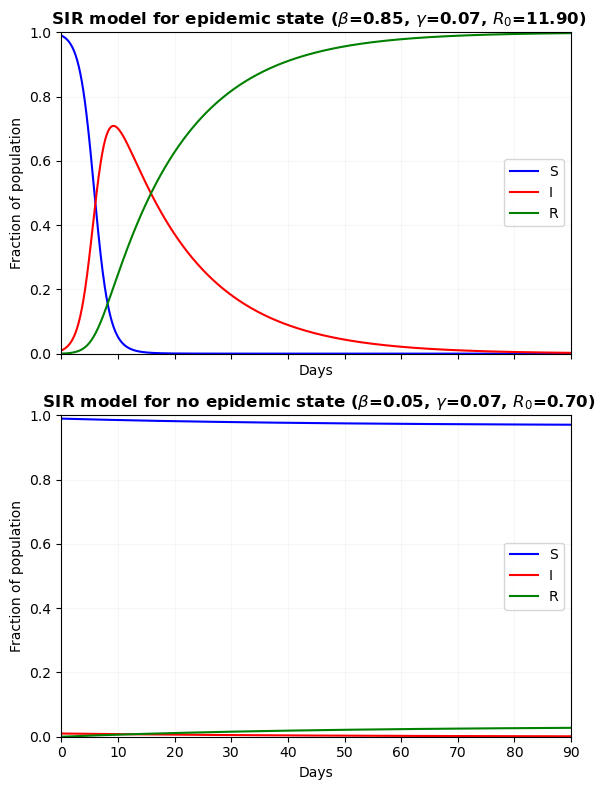

In [219]:
# Plot curves for the two different scenarios 
scenarios_basic = {"epidemic": (0.85, 1 / 14), "no epidemic": (0.05, 1 / 14)}

# Time series plots
fig, ax = plt.subplots(2, 1, figsize=(6, 8), sharex=True)
for i, (name, (beta, gamma)) in enumerate(scenarios_basic.items()):
    t, S, I, R = SIR_basic_solve(y0, beta, gamma)
    ax[i].plot(t, S, color="blue", label="S")
    ax[i].plot(t, I, color="red", label="I")
    ax[i].plot(t, R, color="green", label="R")
    ax[i].set_title(f" SIR model for {name} state ($\\beta$={beta:.2f}, $\\gamma$={gamma:.2f}, $R_0$={beta/gamma:.2f})", weight="bold")
    ax[i].set_xlim(0, 90)
    ax[i].set_ylim(0, 1)
    ax[i].grid(True, alpha=0.1)
    ax[i].set_xlabel("Days")
    ax[i].set_ylabel("Fraction of population")
    ax[i].legend(loc="center right")

plt.tight_layout()


In [220]:
# Initialize grid for stream plot
S_vals = np.linspace(0, 1, 100)
I_vals = np.linspace(0, 1, 100)
S_grid, I_grid = np.meshgrid(S_vals, I_vals)

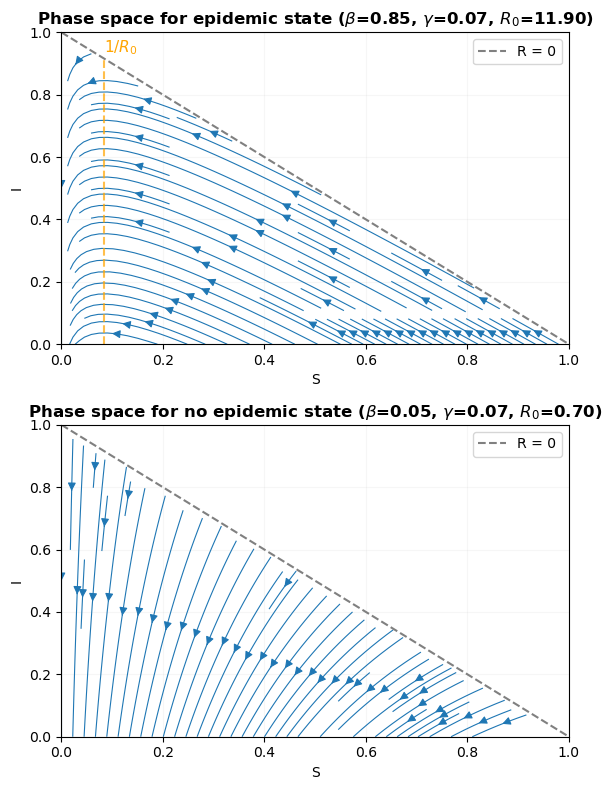

In [221]:
# Plot phase spaces
fig, ax = plt.subplots(2, 1, figsize=(6, 8), sharey=True)
for i, (name, (beta, gamma)) in enumerate(scenarios_basic.items()):
    s_traj = -beta * S_grid * I_grid
    i_traj = beta * S_grid * I_grid - gamma * I_grid

    # Mask invalid region S + I > 1 (R < 0)
    mask = (S_grid + I_grid) <= 1.0
    s_traj = np.where(mask, s_traj, np.nan)
    i_traj = np.where(mask, i_traj, np.nan)

    ax[i].streamplot(
        S_grid, I_grid, s_traj, i_traj, density=1.5, arrowsize=1.2, linewidth=0.8
    )
    ax[i].plot(S_vals, 1.0 - S_vals, "--", color="grey", label="R = 0")

    if beta > gamma:
        s_star = gamma / beta
        ax[i].plot([s_star, s_star], [0, 1 - s_star], "--", color="orange", alpha=0.7)
        ax[i].text(s_star, 1.02 - s_star, "1/$R_0$", color="orange", fontsize=11)

    ax[i].set_title(f"Phase space for {name} state ($\\beta$={beta:.2f}, $\\gamma$={gamma:.2f}, $R_0$={beta/gamma:.2f})", weight="bold")
    ax[i].set_xlim(0, 1)
    ax[i].set_ylim(0, 1)
    ax[i].set_xlabel("S")
    ax[i].set_ylabel("I")
    ax[i].grid(True, alpha=0.1)
    ax[i].legend()

plt.tight_layout()

**1.2** We are given historical data from a case of an influenza outbreak in a boys school with a total of 763 boys. At day 0, one infected boy started the epidemic.
We fit the SIR basic model to the data and estimate the parameters using a least squares procedure.

In [222]:
# Initial data on outbreak
N = 763
days = 14
Y = np.array([1, 3, 8, 28, 75, 221, 291, 255, 235, 190, 125, 70, 28, 12, 5])
I_data = Y/N
t_obs = np.arange(len(Y))

In [223]:
# Residuals function
def residuals(param, t_obs_, I_obs):
    beta, gamma = param
    i0_ = I_obs[0]
    y0_ = [1.0 - i0_, i0_, 0.0]
    t, S, I, R = SIR_basic_solve(y0_, beta, gamma, T=t_obs_[-1], steps=len(t_obs_))
    return I - I_obs

In [224]:
# Find parameters minimizing residuals
param0 = np.array([0.5, 0.1])
sol = least_squares(
    residuals, param0, args=(t_obs, I_data), bounds=([0.0, 0.0], [np.inf, np.inf]))

beta_fit, gamma_fit = sol.x

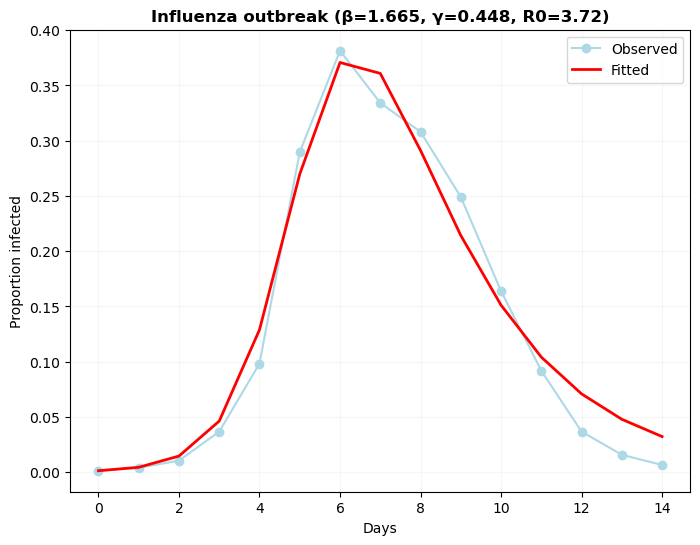

In [225]:
# Plot fitted curve
y0_fit = [1.0 - I_data[0], I_data[0], 0.0]
t_fit, S_fit, I_fit, R_fit = SIR_basic_solve(
    y0_fit, beta_fit, gamma_fit, T=t_obs[-1], steps=len(t_obs)
)

plt.figure(figsize=(8, 6))
plt.plot(t_obs, I_data, "o-", color="lightblue", label="Observed", markersize=6)
plt.plot(t_fit, I_fit, "r-", label="Fitted", linewidth=2)
plt.xlabel("Days")
plt.ylabel("Proportion infected")
plt.title(
    f"Influenza outbreak (β={beta_fit:.3f}, γ={gamma_fit:.3f}, R0={beta_fit/gamma_fit:.2f})",
    weight="bold",
)
plt.grid(True, alpha=0.1)
plt.legend()


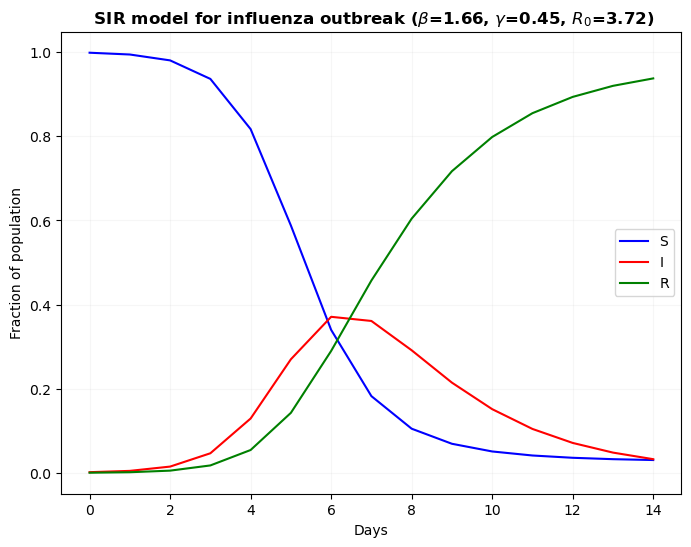

In [226]:
# Plot SIR curves
plt.figure(figsize=(8, 6))
plt.plot(t_fit, S_fit, color="blue", label="S")
plt.plot(t_fit, I_fit, color="red", label="I")
plt.plot(t_fit, R_fit, color="green", label="R")
plt.xlabel("Days")
plt.ylabel("Fraction of population")
plt.title(f' SIR model for influenza outbreak ($\\beta$={beta_fit:.2f}, $\\gamma$={gamma_fit:.2f}, $R_0$={beta_fit/gamma_fit:.2f})', weight="bold")
plt.grid(True, alpha=0.1)
plt.legend()

**1.3** In the school outbreak, the estimated $R_0 > 1$ confirms the epidemic scenario. To mitigate or prevent the spread, two vaccination strategies could be adopted:
1. Vaccine students before school starts. At the beginning of the school term, vaccinated students can be moved directly to the R population, reducing the S pool. We expect smaller outbreaks, especially for high coverage levels.
2. Emergency mass vaccination campaign. Once the influenza starts spreading, the school could react by vaccinating $u$ students per day. The effectiveness of such campaign depends on the time immunity takes to develop after the vaccine.

In [227]:
results = {}
# Strategy 1: pre-vaccinate before term
vaccine_efficacy = 0.55
coverage_levels = [1.0, 0.6, 0.0]  # include baseline 0.0

i0_school = I_data[0]
s0_school = 1.0 - i0_school
r0_school = 0.0

for cov in coverage_levels:
    p = cov * vaccine_efficacy
    s0_prev = s0_school * (1.0 - p)
    i0_prev = i0_school
    r0_prev = s0_school * p  # CHANGED: pre-vaccinated go to R
    y0_prev = [s0_prev, i0_prev, r0_prev]
    # CHANGED: np.isclose instead of exact sum
    assert np.isclose(np.sum(y0_prev), 1.0)
    t_prev, S_prev, I_prev, R_prev = SIR_basic_solve(
        y0_prev, beta_fit, gamma_fit, T=t_obs[-1], steps=len(t_obs)
    )
    results[f"{cov}"] = {"time": t_prev, "S": S_prev, "I": I_prev, "R": R_prev}

In [228]:
# Strategy 2: mass reactive vaccination campaign
def SIR_mass_vaccine(t, z, beta, gamma, u, day_start=3.0): # day_start controls when influenza is identified
    S, I, R = z[0], z[1], z[2]
    u_start = u if t >= day_start else 0.0
    u_eff = min(u_start, S) # prevent negative S
    dSdt = -beta * S * I - u_eff
    dIdt = beta * S * I - gamma * I
    dRdt = gamma * I + u_eff
    return [dSdt, dIdt, dRdt]

def SIR_mass_vaccine_solve(y0, beta, gamma, u, T = 90, steps = 1000):
    t_span = (0, T)
    t_eval = np.linspace(0, T, steps)  
    sol = solve_ivp(SIR_mass_vaccine, t_span, y0, t_eval = t_eval, args=(beta, gamma,u))
    return sol.t, sol.y[0], sol.y[1], sol.y[2]

y0_mass = [s0_school, i0_school, 0.0]

vaccinations_per_day = 20  
u = vaccinations_per_day / N  # fraction per day
t_mass, S_mass, I_mass, R_mass = SIR_mass_vaccine_solve(y0_mass, beta_fit, gamma_fit, u, T=t_obs[-1], steps=len(t_obs))
results["mass_vacc"] = {"time": t_mass, "S": S_mass, "I": I_mass, "R": R_mass}


100% vaccinated students: maximum infected 29 on day 14
60% vaccinated students: maximum infected 119 on day 10
0% vaccinated students: maximum infected 282 on day 6
Reactive vaccination: maximum infected 251 on day 6


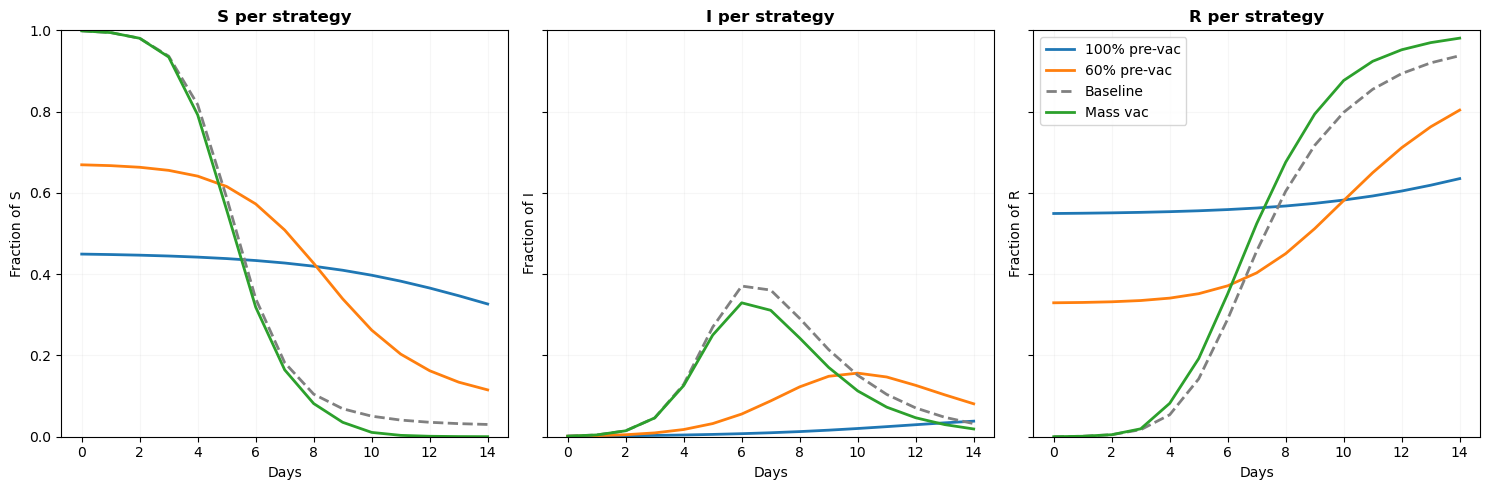

In [229]:
# Plots comparing strategies for S, I, R
variables = ["S", "I", "R"]
fig, ax = plt.subplots(1, 3, figsize=(15, 5), sharex=True, sharey=True)

for j, var in enumerate(variables):
    for cov in coverage_levels:
        key = f"{cov}"
        label = "Baseline" if cov == 0.0 else f"{cov:.0%} pre-vac"
        style = "--" if cov == 0.0 else "-"
        color = "grey" if cov == 0.0 else None
        ax[j].plot(
            results[key]["time"],
            results[key][var],
            style,
            linewidth=2,
            color=color,
            label=label,
        )
    ax[j].plot(results["mass_vacc"]["time"], results["mass_vacc"][var], linewidth=2, label="Mass vac")
    ax[j].set_title(f"{var} per strategy", weight="bold")
    ax[j].set_xlabel("Days")
    ax[j].set_ylabel(f"Fraction of {var}")
    ax[j].grid(True, alpha=0.1)
    ax[j].set_ylim(0, 1)

ax[-1].legend()
plt.tight_layout()

# Summary stats
for strategy in results.keys():
    max_infected = int(np.max(results[strategy]["I"]) * N)
    day_peak = int(np.argmax(results[strategy]["I"]))
    if strategy == "mass_vacc":
        print(f"Reactive vaccination: maximum infected {max_infected} on day {day_peak}")
    else:
        print(f"{float(strategy):.0%} vaccinated students: maximum infected {max_infected} on day {day_peak}")

<function matplotlib.pyplot.tight_layout(*, pad: 'float' = 1.08, h_pad: 'float | None' = None, w_pad: 'float | None' = None, rect: 'tuple[float, float, float, float] | None' = None) -> 'None'>

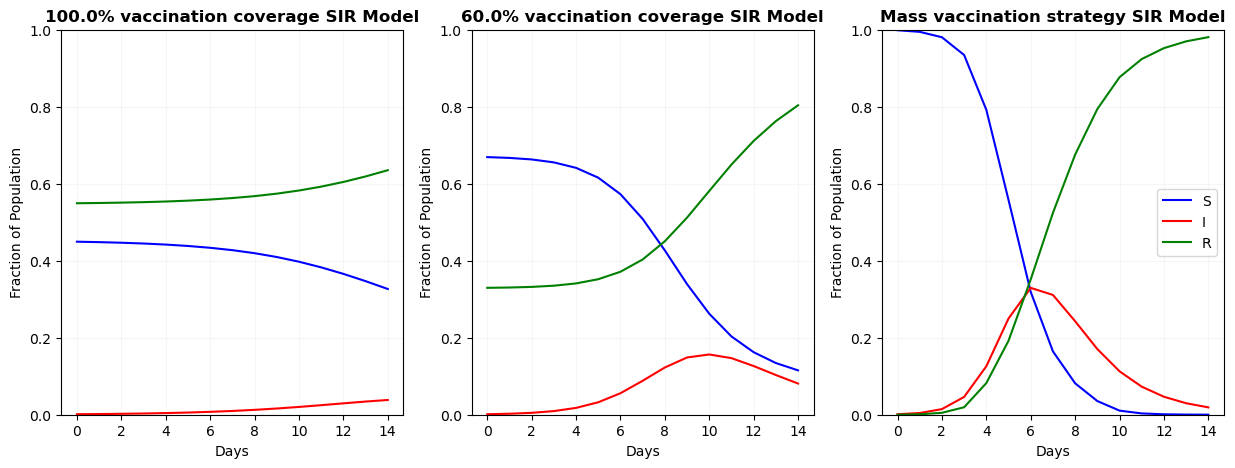

In [230]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
results_nobaseline = {k: v for k, v in results.items() if k != "0.0"}

for x, (scenario_name, scenario_data) in enumerate(results_nobaseline.items()):
    # Plot S, I, R for each scenario different from baseline

    ax[x].plot(scenario_data['time'], scenario_data['S'], 
                    color= "blue", label="S")
    ax[x].plot(scenario_data['time'], scenario_data['I'], 
                    color="red", label="I")
    ax[x].plot(scenario_data['time'], scenario_data['R'], 
                    color="green", label="R")
    if x == 0 or x == 1:
        ax[x].set_title(f"{float(scenario_name)*100}% vaccination coverage SIR Model", weight="bold")
    ax[x].set_xlabel("Days", fontsize=10)
    ax[x].set_ylabel("Fraction of Population", fontsize=10)
    ax[x].grid(True, alpha=0.1)
    ax[x].set_ylim(0, 1)

ax[-1].set_title(f"Mass vaccination strategy SIR Model", weight="bold")
ax[-1].legend()
plt.tight_layout

**Problem 2: Demography**

We add more terms to the basic SIR model, i.e. birth and death rates to consider demographic changes.

**2.1**  Initially we add birth and natural death rate terms, so that $N_p$ stays constant. Specifically in this case, birth and death rates are both equal to $\mu$.

For $R_0 > 1$, the model will now reach the endemic state, and exhibits oscillatory behavior.

In [231]:
# Implement SIR with demogrpahy
def SIR_demo(t, z, beta, gamma, mu): # where mu = death rate = birth rate
    S, I, R = z[0], z[1], z[2]
    dSdt = mu - beta * S * I - mu*S
    dIdt = beta * S * I - (gamma+mu)*I
    dRdt = gamma * I - mu * R
    return [dSdt, dIdt, dRdt]

In [232]:
def SIR_demo_solve(y0, beta, gamma, mu, T = 300, steps = 1000):
    t_span = (0, T)
    t_eval = np.linspace(0, T, steps)  
    sol = solve_ivp(SIR_demo, t_span, y0, t_eval = t_eval, args=(beta, gamma,mu))
    return sol.t, sol.y[0], sol.y[1], sol.y[2]

In [233]:
# Plot curves for the two different scenarios, as in Problem 1
mu = 1/(70*365)
scenarios_demo = {"epidemic": (0.85, 1/14, mu), "no epidemic": (0.05, 1/14, mu)} 
years = 60

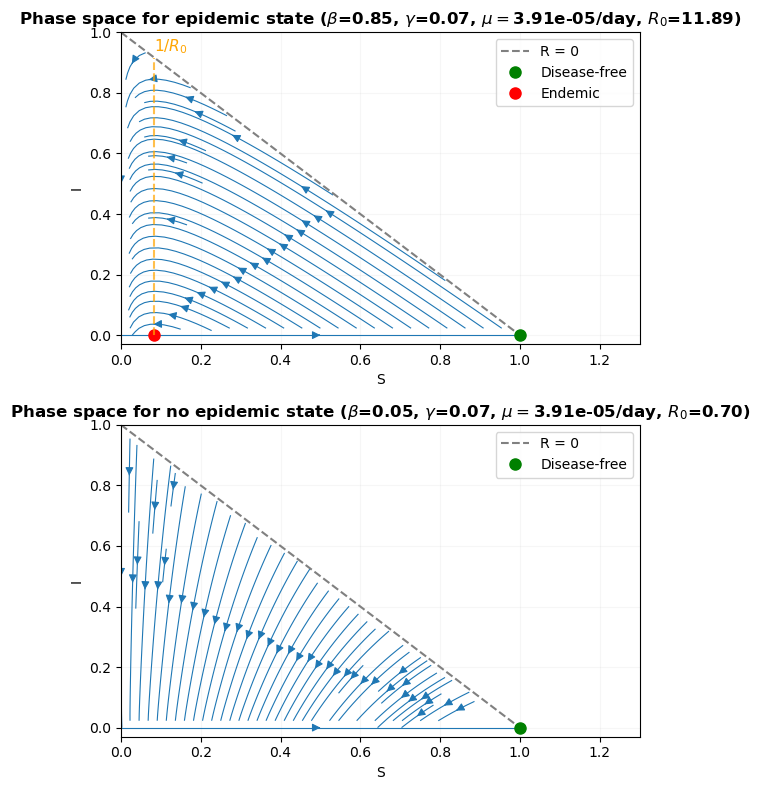

In [235]:
fig, ax = plt.subplots(2, 1, figsize=(6, 8), sharey=True)
for i, (name, (beta, gamma, mu_)) in enumerate(scenarios_demo.items()):
    s_traj = mu_ - beta * S_grid * I_grid - mu_ * S_grid
    i_traj = beta * S_grid * I_grid - (gamma + mu_) * I_grid
    mask = (S_grid + I_grid) <= 1.0
    s_traj = np.where(mask, s_traj, np.nan)
    i_traj = np.where(mask, i_traj, np.nan)

    ax[i].streamplot(
        S_grid, I_grid, s_traj, i_traj, density=1.5, arrowsize=1.2, linewidth=0.8
    )
    ax[i].plot(S_vals, 1.0 - S_vals, "--", color="grey", label="R = 0")
    ax[i].plot(1.0, 0.0, "o", markersize=8, color="green", label="Disease-free")

    R0_demo = beta / (gamma + mu_)
    if R0_demo > 1.0:
        s_star = 1.0 / R0_demo
        i_star = mu_ / beta * (R0_demo - 1.0)
        ax[i].plot(s_star, i_star, "o", markersize=8, color="red", label="Endemic")
        ax[i].plot([s_star, s_star], [0, 1 - s_star], "--", color="orange", alpha=0.7)
        ax[i].text(s_star, 1.02 - s_star, "1/$R_0$", color="orange", fontsize=11)

    # CHANGED: correct mu formatting and axis limits
    ax[i].set_title(f"Phase space for {name} state ($\\beta$={beta:.2f}, $\\gamma$={gamma:.2f}, $\\mu =${mu_:.2e}/day, $R_0$={R0_demo:.2f})", weight="bold")
    ax[i].set_xlim(0, 1.3)
    ax[i].set_ylim(-0.03, 1)
    ax[i].set_xlabel("S")
    ax[i].set_ylabel("I")
    ax[i].grid(True, alpha=0.1)
    ax[i].legend()

plt.tight_layout()

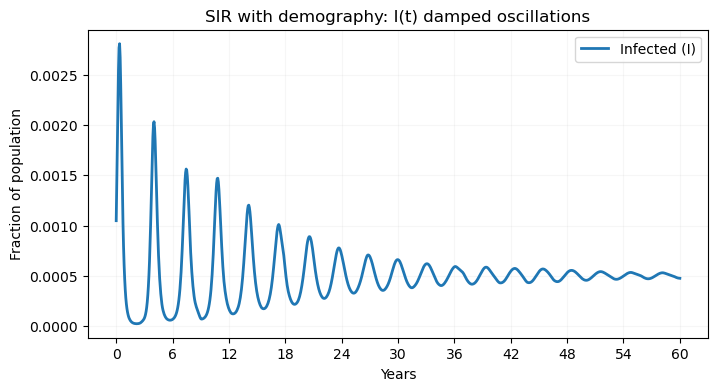

In [236]:
# Oscillations dynamics for endemic state
# Choose initial conditions
i0_2 = 0.0005 + np.random.rand() * 1e-3
s0_2 = 0.1
r0_2 = 1.0 - (i0_2 + s0_2)
y0_2 = [s0_2, i0_2, r0_2]

beta_ep, gamma_ep, mu_ep = scenarios_demo["epidemic"]
years = 60
t_long, S_long, I_long, R_long = SIR_demo_solve(
    y0_2, beta_ep, gamma_ep, mu_ep, T=years * 365
)

plt.figure(figsize=(8, 4))
plt.plot(t_long, I_long, linewidth=2, label="Infected (I)")
ticks = np.linspace(0, years * 365, 11)
labels = [f"{int(x/365)}" for x in ticks]
plt.xticks(ticks, labels)
plt.xlabel("Years")
plt.ylabel("Fraction of population")
plt.title("SIR with demography: I(t) damped oscillations")
plt.grid(True, alpha=0.1)
plt.legend()

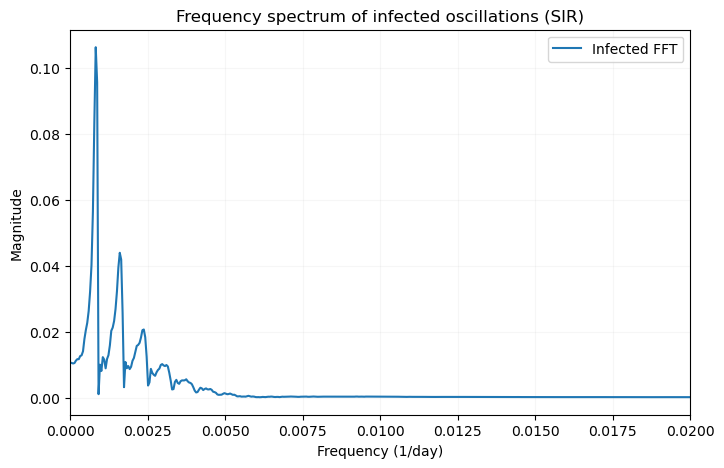

Most prominent infection frequency: 0.00082 (1/day)
Period ≈ 1217.88 days (3.34 years)


In [237]:
# FFT spectrum
N_fft = len(I_long)
dt = t_long[1] - t_long[0]
freqs = fft.fftfreq(N_fft, dt)
fft_I = fft.fft(I_long)
mask = freqs > 0
freqs_pos = freqs[mask]
fft_mag = np.abs(fft_I[mask])

plt.figure(figsize=(8, 5))
plt.plot(freqs_pos, fft_mag, label="Infected FFT")
plt.xlabel("Frequency (1/day)")
plt.ylabel("Magnitude")
plt.title("Frequency spectrum of infected oscillations (SIR)")
plt.xlim(0, 0.02)
plt.grid(True, alpha=0.1)
plt.legend()
plt.show()

dominant_freq = freqs_pos[np.argmax(fft_mag)]
print(f"Most prominent infection frequency: {dominant_freq:.5f} (1/day)")
print(f"Period ≈ {1/dominant_freq:.2f} days ({(1/dominant_freq)/365:.2f} years)")

In [238]:
# Expected period from formulas
R0_val = beta_ep / (gamma_ep + mu_ep)
A = 1.0 / (mu_ep * (R0_val - 1.0))  # mean age at infection
G = 1.0 / (mu_ep + gamma_ep)        # period of host infectivity
T_exp = 2 * np.pi * np.sqrt(A * G)
print(f"Expected frequency and period from model: f = {1/T_exp:.5f}, T = {T_exp:.2f}")

Expected frequency and period from model: f = 0.00088, T = 1138.25


**3.2** We consider a model with an infection induced mortality term, based on $\rho$: the probability of dying while infected. Now, $N_p$ is not constant anymore, and as $\rho$ approaches 1, the infection becomes immediately fatal.

In [239]:
N_demo = 10000
def SIR_demo_mortality(t, z, beta, gamma, mu, rho, vu):
    X, Y, Z = z[0], z[1], z[2]  # X=S*N, Y=I*N, Z=R*N 
    N_curr= X + Y + Z           # Current total population
    # Avoid division by zero if population collapses
    if N_curr <= 0:
        return [0.0, 0.0, 0.0]
    dXdt = vu - beta * X * Y / N_curr - mu * X
    dYdt = beta * X * Y / N_curr - (gamma + mu) / (1 - rho) * Y
    dZdt = gamma * Y - mu * Z
    return [dXdt, dYdt, dZdt]

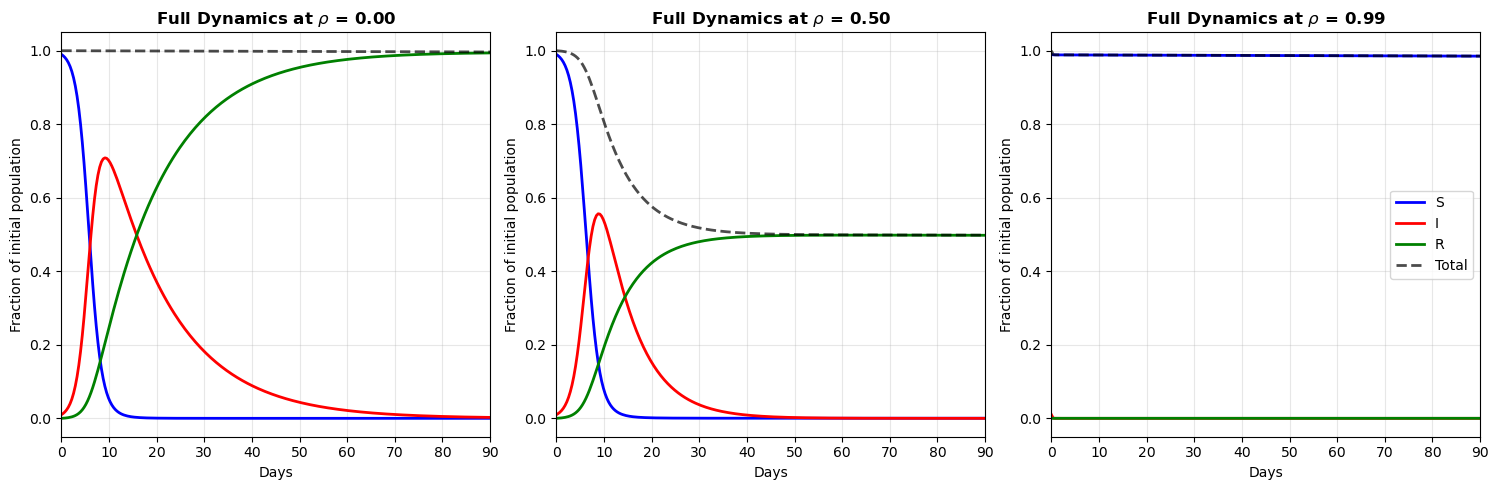

In [240]:
t_m = np.linspace(0, 365, 1000)
beta_m, gamma_m, mu_m, vu_m = 0.85, 1 / 14, 1 / (70 * 365), 0.01

x0_abs = 0.99 * N_demo
y0_abs = 0.01 * N_demo
z0_abs = 0.0 * N_demo

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
for i, rho in enumerate([0.0, 0.5, 0.99]):
    sol = solve_ivp(
        SIR_demo_mortality,
        (0, 365),
        [x0_abs, y0_abs, z0_abs],
        t_eval=t_m,
        args=(beta_m, gamma_m, mu_m, rho, vu_m),
    )
    X_frac = sol.y[0] / N_demo
    Y_frac = sol.y[1] / N_demo
    Z_frac = sol.y[2] / N_demo
    total_frac = (sol.y[0] + sol.y[1] + sol.y[2]) / N_demo

    ax[i].plot(t_m, X_frac, "-", color="blue", label="S", linewidth=2)
    ax[i].plot(t_m, Y_frac, "-", color="red", label="I", linewidth=2)
    ax[i].plot(t_m, Z_frac, "-", color="green", label="R", linewidth=2)
    ax[i].plot(t_m, total_frac, "--", color="black", label="Total", alpha=0.7, linewidth=2)
    ax[i].set_title(f'Full Dynamics at $\\rho$ = {rho:.2f}', weight="bold")
    ax[i].set_xlabel("Days")
    ax[i].set_ylabel("Fraction of initial population")
    ax[i].set_xlim(0, 90)
    ax[i].grid(True, alpha=0.3)

ax[-1].legend()
plt.tight_layout()

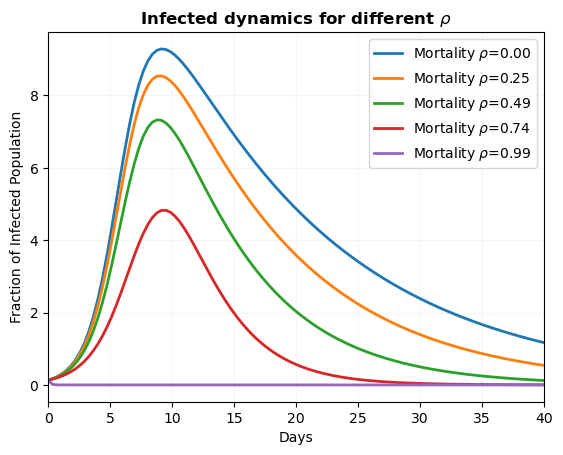

In [241]:
for rho in np.linspace(0, 0.99, 5):
    T = 365
    t_span = (0, T)
    t_eval = t
    sol = solve_ivp(SIR_demo_mortality, t_span, [x0_abs, y0_abs, z0_abs], t_eval=t_m, args=(beta_m, gamma_m, mu_m, rho, vu_m))
    Y_fraction = sol.y[1] / N
    plt.plot(t_m, Y_fraction, label=f"Mortality $\\rho$={rho:.2f}", linewidth=2)

plt.title(f'Infected dynamics for different $\\rho$', weight = "bold")
plt.grid(True, alpha = 0.1)
plt.xlim(0,40)
plt.xlabel('Days')
plt.ylabel('Fraction of Infected Population')
plt.legend()
    

## Problem 3

**3.1** The SEIR is a variant of the SIR model that includes a latent period, where the host is infected but not yet infectious. The average duration of such latent period is given by $1/\sigma$. We assume S + E + I + R = 1, as before.

In [242]:
# Implement SEIR model with optional seasonal forcing (for later)
def SEIR(t, z, beta, gamma, mu, sigma, seasonal=False, beta1=0.2, omega=2*np.pi/365):
    S, E, I, R = z
    # If seasonal is True, beta becomes time-dependent
    beta_t = beta * (1.0 + beta1 * np.cos(omega * t)) if seasonal else beta
    dSdt = mu - beta_t * S * I - mu * S
    dEdt = beta_t * S * I - (mu + sigma) * E
    dIdt = sigma * E - (mu + gamma) * I
    dRdt = gamma * I - mu * R
    return [dSdt, dEdt, dIdt, dRdt]


In [243]:
def SEIR_solve(y0, beta, gamma, mu, sigma, T=90, steps=1000, seasonal=False, beta1=0.2, omega=2*np.pi/365):
    t_span = (0, T)
    t_eval = np.linspace(0, T, steps)
    sol = solve_ivp(SEIR, t_span, y0, t_eval=t_eval, args=(beta, gamma, mu, sigma, seasonal, beta1, omega))
    S, E, I, R = sol.y
    return sol.t, S, E, I, R

In [186]:
# Initial conditions, with E class
y0_seir = [0.99, 0.01, 0.0, 0.0]

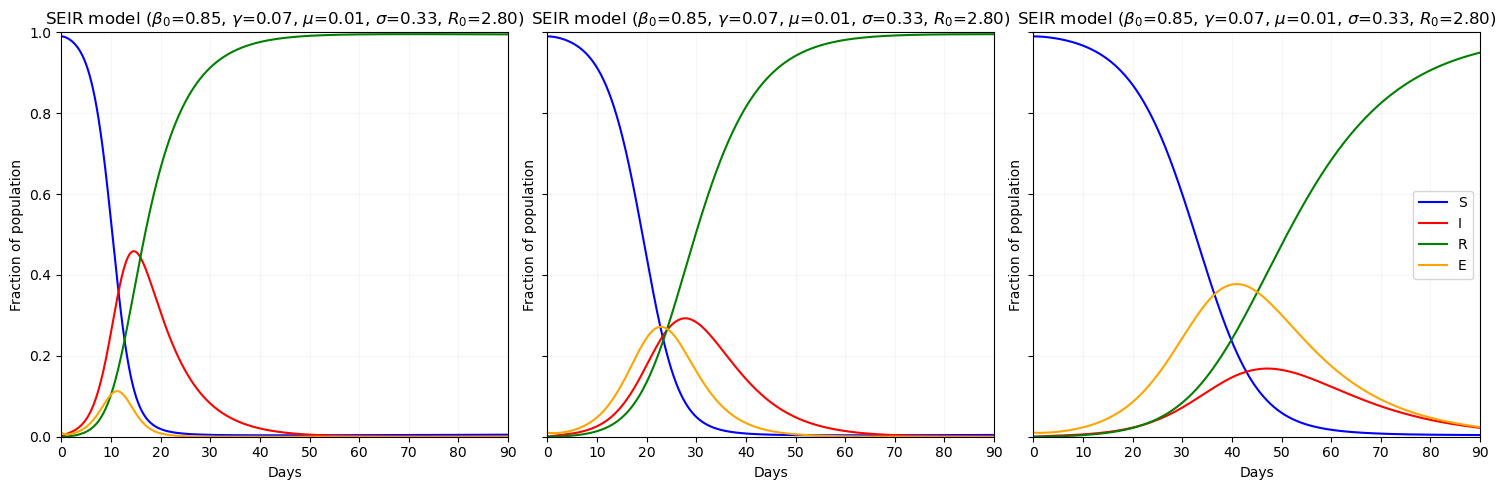

In [244]:
# Plot different scenarios for SEIR model
mu_seir = 1 / (70 * 365)
beta0 = 0.85
gamma_seir = 1 / 7

scenarios_seir = [
    (beta0, gamma_seir, mu_seir, 1 / 1),
    (beta0, gamma_seir, mu_seir, 1 / 5),
    (beta0, gamma_seir, mu_seir, 1 / 14),
]

fig, ax = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
for i, (b0, g0, m0, sigma_) in enumerate(scenarios_seir):
    t, S, E, I, R = SEIR_solve(y0_seir, b0, g0, m0, sigma_)
    R0_seir = (b0 * sigma_) / ((sigma_ + m0) * (g0 + m0))
    ax[i].plot(t, S, "b", label="S")
    ax[i].plot(t, I, "r", label="I")
    ax[i].plot(t, R, "g", label="R")
    ax[i].plot(t, E, color="orange", label="E")
    ax[i].set_title(f"SEIR model ($\\beta_0$={beta0:.2f}, $\gamma$={gamma:.2f}, $\mu$={mu*365:.2f}, $\sigma$={sigma:.2f}, $R_0$={R0_SEIR:.2f})")
    ax[i].set_xlim(0, 90)
    ax[i].set_ylim(0, 1)
    ax[i].grid(True, alpha=0.1)
    ax[i].set_xlabel("Days")
    ax[i].set_ylabel("Fraction of population")
    if i == 2:
        ax[i].legend(loc="center right")

plt.tight_layout()

**3.2** Finally, we add seasonal effects into the model, by introducing a time-varying sinusoidal rate of
infection:

$\beta(t) = \beta_0 * (1 + \beta_1 * cos(\omega*t))$

where $\beta_0$ is the average transmission rate, $\beta_1$ the amplitude of seasonal variation, and $\omega$ the frequency of oscillation.
This seasonal variation can be used to describe the natural fluctuations in disease transmission observed in many infectious diseases, such as influenza peaking during winter months, or childhood diseases that follow school calendar patterns.

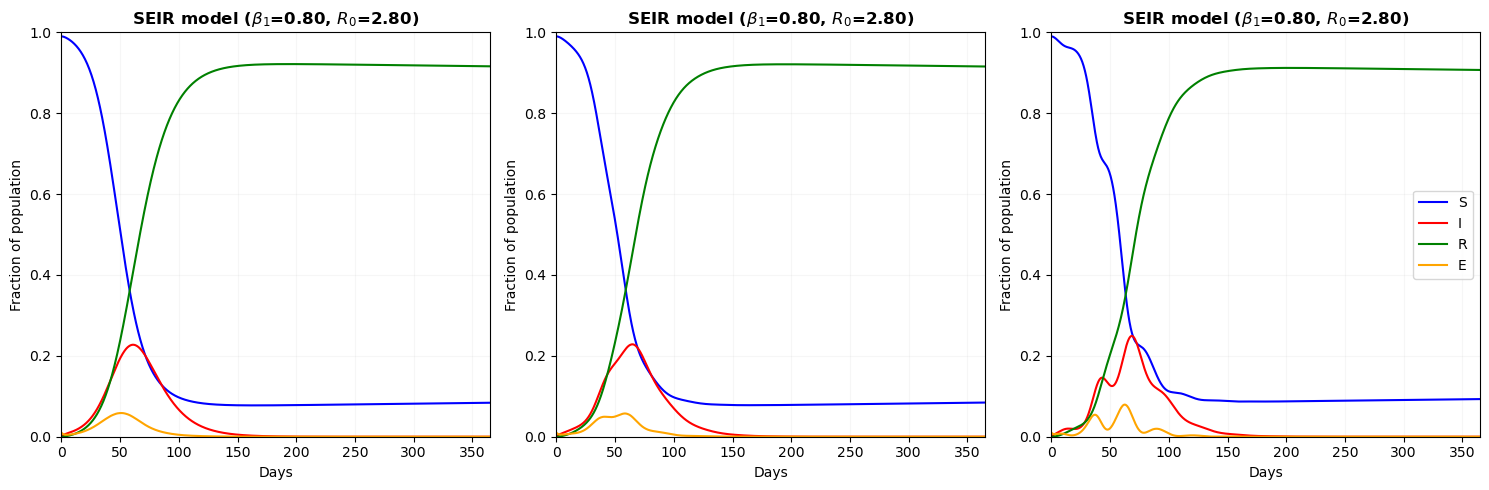

In [245]:
# Seasonal forcing scenarios
beta0_forced = 0.2
omega_month = 2 * np.pi / 30
gamma_forced = 1 / 14
sigma_forced = 1 / 3

scenarios_forced = [
    (beta0_forced, gamma_forced, mu_seir, sigma_forced, 0.01, omega_month),
    (beta0_forced, gamma_forced, mu_seir, sigma_forced, 0.2, omega_month),
    (beta0_forced, gamma_forced, mu_seir, sigma_forced, 0.8, omega_month),
]

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
for i, (b0, g0, m0, sigma_, b1, omg) in enumerate(scenarios_forced):
    t, S, E, I, R = SEIR_solve(
        y0_seir, b0, g0, m0, sigma_, T=365, steps=1000, seasonal=True, beta1=b1, omega=omg
    )
    R0_seir = (b0 * sigma_) / ((sigma_ + m0) * (g0 + m0))
    ax[i].plot(t, S, "b", label="S")
    ax[i].plot(t, I, "r", label="I")
    ax[i].plot(t, R, "g", label="R")
    ax[i].plot(t, E, color="orange", label="E")
    ax[i].set_title(f"SEIR model ($\\beta_1$={beta1:.2f}, $R_0$={R0_SEIR:.2f})", weight = "bold")
    ax[i].set_xlim(0, 365)
    ax[i].set_ylim(0, 1)
    ax[i].grid(True, alpha=0.1)
    ax[i].set_xlabel("Days")
    ax[i].set_ylabel("Fraction of population")
    if i == 2:
        ax[i].legend(loc="center right")

plt.tight_layout()


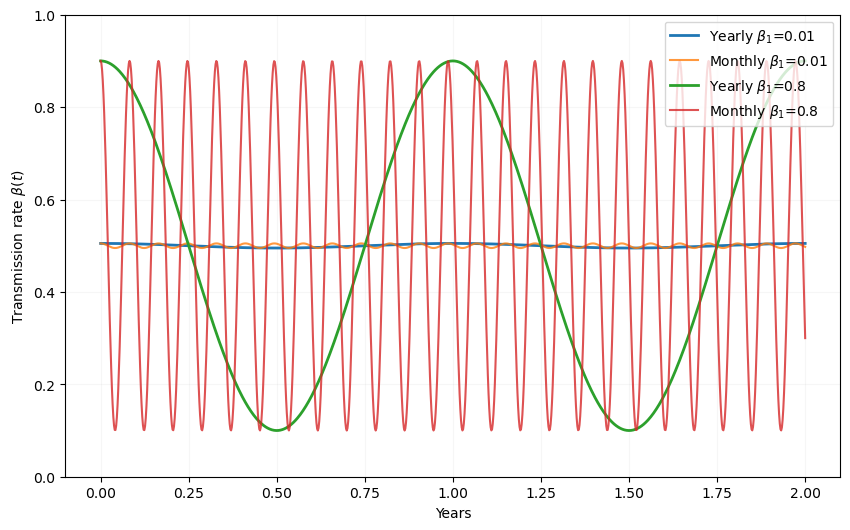

In [246]:
# seasonal beta(t) 
beta0_demo = 0.5
omega_year = 2 * np.pi / 365
omega_months = 2 * np.pi / 30
t_beta = np.linspace(0, 2 * 365, 1000)
beta1_vals = [0.01, 0.8]

plt.figure(figsize=(10, 6))
for b1 in beta1_vals:
    beta_t_year = beta0_demo * (1 + b1 * np.cos(omega_year * t_beta))
    plt.plot(t_beta / 365, beta_t_year, label=fr"Yearly $\beta_1$={b1}", linewidth=2)

    beta_t_month = beta0_demo * (1 + b1 * np.cos(omega_months * t_beta))
    plt.plot(t_beta / 365, beta_t_month, alpha=0.8, label=fr"Monthly $\beta_1$={b1}")

plt.ylim(0, 1)
plt.xlabel("Years")
plt.ylabel(r"Transmission rate $\beta(t)$")
plt.legend(loc=1)
plt.grid(True, alpha=0.1)

